<a href="https://colab.research.google.com/github/Grupo-LCE0212/Estatistica/blob/main/Tarefa13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Tarefa 13 - Ciências dos Alimentos - Python

Nome: Iago Aparecido Dias dos Santos N​​° USP:16873011

Nome: João Pedro Paschoalini N​​° USP:17831089

Nome: Maria Eduarda Porta N° USP: 17074105



Neste trabalho será utilizada a base **Rice (Cammeo and Osmancik)**, disponibilizada pelo **UCI Machine Learning Repository**.

A base contém dados de **3.810 grãos de arroz individuais**, pertencentes às variedades **Cammeo** e **Osmancik**. Cada linha da base representa um grão de arroz, enquanto as colunas apresentam características morfológicas obtidas a partir de imagens digitais dos grãos.

A base possui sete variáveis quantitativas relacionadas ao tamanho e ao formato dos grãos, como área, perímetro, comprimento dos eixos e excentricidade.

Neste trabalho, será utilizada principalmente a variável **`Area`**, que representa a área ocupada pelo grão na imagem.

As duas variedades presentes na base também permitirão comparar a variabilidade das características entre os grupos Cammeo e Osmancik.

**Fonte:** UCI Machine Learning Repository  
**Base:** Rice (Cammeo and Osmancik)  
**Instituição responsável:** University of California, Irvine  
**Data de acesso:** 01/10/2026  
**Link:** https://archive.ics.uci.edu/dataset/545/rice+cammeo+and+osmancik

## Carregamento e inspeção dos dados

Nesta etapa, faremos o carregamento da base de dados **Rice (Cammeo and Osmancik)** diretamente do *UCI Machine Learning Repository* utilizando a biblioteca oficial `ucimlrepo`. Em seguida, faremos uma inspeção inicial da estrutura da base para verificar suas dimensões, os tipos de variáveis disponíveis, a presença de valores ausentes e uma análise descritiva estatística preliminar da nossa variável de interesse principal: a `Area`.

In [148]:
# Instalação da biblioteca do repositório UCI
!pip install ucimlrepo

### Importação das Bibliotecas e Carregamento dos Dados

Vamos importar as bibliotecas necessárias para a análise de dados (`pandas`, `numpy`, `matplotlib`, `scipy.stats`) e carregar a base utilizando o ID correspondente ao dataset Rice (ID 545).

In [149]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from ucimlrepo import fetch_ucirepo

# Carregar o dataset Rice (Cammeo and Osmancik)
rice_cammeo_and_osmancik = fetch_ucirepo(id=545)

# Obter as variáveis (features) e a classe alvo (target)
X = rice_cammeo_and_osmancik.data.features
y = rice_cammeo_and_osmancik.data.targets

# Unir as características e a classe em um único DataFrame
df = pd.concat([X, y], axis=1)

# Exibir as 5 primeiras linhas do DataFrame
display(df.head())

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
0,15231,525.578979,229.749878,85.093788,0.928882,15617,0.572896,Cammeo
1,14656,494.311005,206.020065,91.730972,0.895405,15072,0.615436,Cammeo
2,14634,501.122009,214.106781,87.768288,0.912118,14954,0.693259,Cammeo
3,13176,458.342987,193.337387,87.448395,0.891861,13368,0.640669,Cammeo
4,14688,507.166992,211.743378,89.312454,0.906691,15262,0.646024,Cammeo


### Inspeção da Estrutura e Verificação de Dados Ausentes

Aqui verificamos as dimensões do conjunto de dados, as colunas existentes, seus tipos de dados e se há algum valor nulo ou faltante que precise ser tratado.

In [150]:
# Número de linhas e colunas
print(f"Dimensões do dataset (linhas, colunas): {df.shape}\n")

# Nome das colunas
print("Nomes das colunas presentes no DataFrame:")
print(df.columns.tolist(), "\n")

# Informações gerais e tipos de dados
print("Informações gerais do DataFrame:")
df.info()

# Verificação de valores ausentes por coluna
print("\nQuantidade de valores ausentes por coluna:")
print(df.isnull().sum())

Dimensões do dataset (linhas, colunas): (3810, 8)

Nomes das colunas presentes no DataFrame:
['Area', 'Perimeter', 'Major_Axis_Length', 'Minor_Axis_Length', 'Eccentricity', 'Convex_Area', 'Extent', 'Class'] 

Informações gerais do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3810 entries, 0 to 3809
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Area               3810 non-null   int64  
 1   Perimeter          3810 non-null   float64
 2   Major_Axis_Length  3810 non-null   float64
 3   Minor_Axis_Length  3810 non-null   float64
 4   Eccentricity       3810 non-null   float64
 5   Convex_Area        3810 non-null   int64  
 6   Extent             3810 non-null   float64
 7   Class              3810 non-null   object 
dtypes: float64(5), int64(2), object(1)
memory usage: 238.3+ KB

Quantidade de valores ausentes por coluna:
Area                 0
Perimeter            0
Major_Axis_Length 

### Análise Descritiva da Variável Area por Variedade de Arroz

Para compreender a distribuição da variável **`Area`**, faremos uma análise descritiva agrupando os dados pelas duas variedades de arroz: **Cammeo** e **Osmancik**.

In [151]:
# Análise estatística descritiva da variável 'Area' agrupada por 'Class'
estatisticas_area = df.groupby('Class')['Area'].describe()

# Exibir a tabela descritiva contendo média, desvio padrão, mínimo, quartis (25%, 50%, 75%) e máximo
display(estatisticas_area)

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
Cammeo,1630.0,14162.892025,1286.770521,9908.0,13289.25,14212.0,14997.0,18913.0
Osmancik,2180.0,11549.783486,1041.908607,7551.0,10850.50,11552.5,12269.0,15420.0


### Interpretação inicial

A variável `Area` apresenta valores médios diferentes entre as duas variedades de arroz.

Os grãos Cammeo apresentaram área média de aproximadamente 14162,89, enquanto os grãos Osmancik apresentaram média de aproximadamente 11549,78.

Também foi observada maior dispersão dos valores de área na variedade Cammeo, cujo desvio-padrão foi aproximadamente 1286,77, em comparação com 1041,91 para Osmancik.

A base não apresenta valores ausentes, portanto não foi necessário realizar tratamento de dados faltantes nesta etapa.

## Distribuição Normal

Nesta seção, estudaremos o modelo teórico da **Distribuição Normal** (ou Gaussiana), avaliando suas propriedades fundamentais, comportamento geométrico e como ela se aplica para aproximar a modelagem da variável **`Area`** especificamente para a variedade de arroz **Cammeo**.

### Definição da Distribuição Normal

A distribuição Normal é a distribuição de probabilidade contínua mais importante da Estatística. Ela é comumente utilizada para modelar fenômenos naturais, biológicos e medições físicas de processos produtivos ou de alimentos, onde os valores tendem a se agrupar simetricamente em torno de um valor central.

**Principais Características:**
1. **Contínua:** A variável sob estudo pode assumir qualquer valor dentro de um intervalo de números reais (não apenas valores inteiros).
2. **Simétrica:** A distribuição apresenta formato de sino, sendo perfeitamente simétrica em relação ao seu centro. Isso implica que a média, a mediana e a moda coincidem no mesmo ponto central.
3. **Assíntota:** As caudas da curva se estendem infinitamente em ambas as direções, aproximando-se do eixo horizontal sem nunca tocá-lo.

**Função Densidade de Probabilidade (FDP):**
A probabilidade de uma variável aleatória contínua $X$ em qualquer ponto é descrita por sua função densidade:

$$f(x) = \frac{1}{\sigma \sqrt{2\pi}} e^{-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2}$$

Onde:
* $x$: representa o valor da variável aleatória (no nosso contexto, a área do grão).
* $\mu$ (mi): representa a **média** da população, que determina a posição central (localização) da curva.
* $\sigma$ (sigma): representa o **desvio-padrão** da população, responsável pela dispersão (largura) da curva.
* $\pi$ (pi): constante matemática aproximada em $3,14159$.
* $e$: constante neperiana aproximada em $2,71828$.

**Parâmetros da Distribuição:**
* **Média ($\mu$):** Pode assumir qualquer valor real ($-\infty < \mu < \infty$). Alterar o valor de $\mu$ desloca o pico da curva para a esquerda ou para a direita ao longo do eixo horizontal, sem alterar seu formato geomátrico.
* **Desvio-Padrão ($\sigma$):** Deve ser estritamente maior que zero ($\sigma > 0$). Ele controla a dispersão dos dados. Um desvio-padrão menor ($\sigma$ pequeno) resulta em uma curva estreita e alta (dados concentrados próximos à média); um desvio-padrão maior ($\sigma$ grande) resulta em uma curva achatada e larga (dados dispersos).

**Referências Teóricas:**
* Bussab, W. O., & Morettin, P. A. (2017). *Estatística Básica* (9ª ed.). Saraiva.
* Documentação Oficial do Módulo SciPy Stats: [scipy.stats.norm](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html).

### Gráfico Variando a Média

Abaixo, fixamos o desvio-padrão $\sigma = 2$ e variamos a média $\mu$ em três valores ($0, 5, 10$) para visualizar graficamente o efeito de translação horizontal da curva Normal.

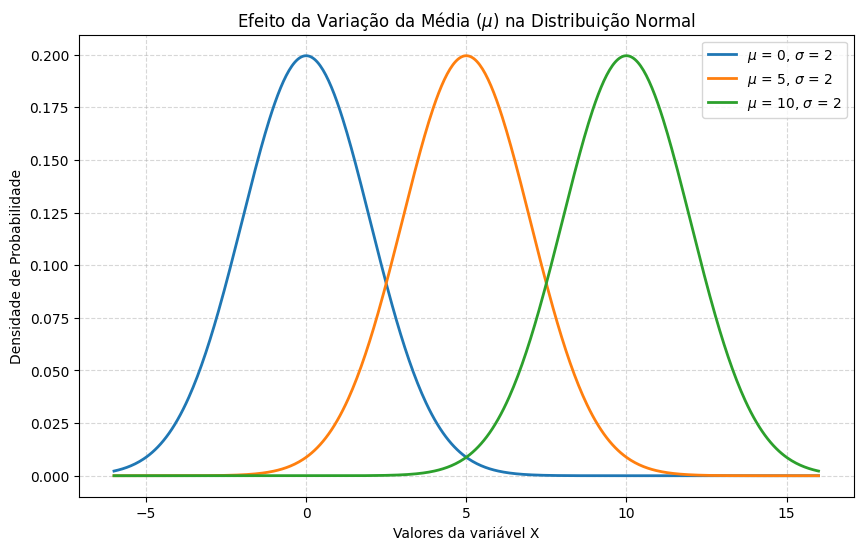

In [152]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Definição do intervalo do eixo x para o gráfico
x = np.linspace(-6, 16, 500)

# Parâmetros
sigma_fixo = 2
medias = [0, 5, 10]

plt.figure(figsize=(10, 6))

for mu in medias:
    # Gerar a curva de densidade normal teórica
    y_pdf = stats.norm.pdf(x, loc=mu, scale=sigma_fixo)
    plt.plot(x, y_pdf, label=fr'$\mu$ = {mu}, $\sigma$ = {sigma_fixo}', linewidth=2)

plt.title(r'Efeito da Variação da Média ($\mu$) na Distribuição Normal')
plt.xlabel('Valores da variável X')
plt.ylabel('Densidade de Probabilidade')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

**Interpretação do gráfico de variação de média:**

Podemos notar que as três curvas possuem exatamente o mesmo formato geométrico (mesma dispersão e mesma altura máxima de pico). O desvio-padrão idêntico garante que o achatamento seja o mesmo. No entanto, o pico central de cada sino se desloca horizontalmente, posicionando-se exatamente sobre os valores de média $\mu = 0$, $\mu = 5$ e $\mu = 10$, respectivamente.

###  Gráfico Variando o Desvio-Padrão

Agora mantemos a média fixa em $\mu = 0$ e variamos o desvio-padrão $\sigma$ ($1, 2, 4$) para observar como a dispersão afeta a curva teórica.

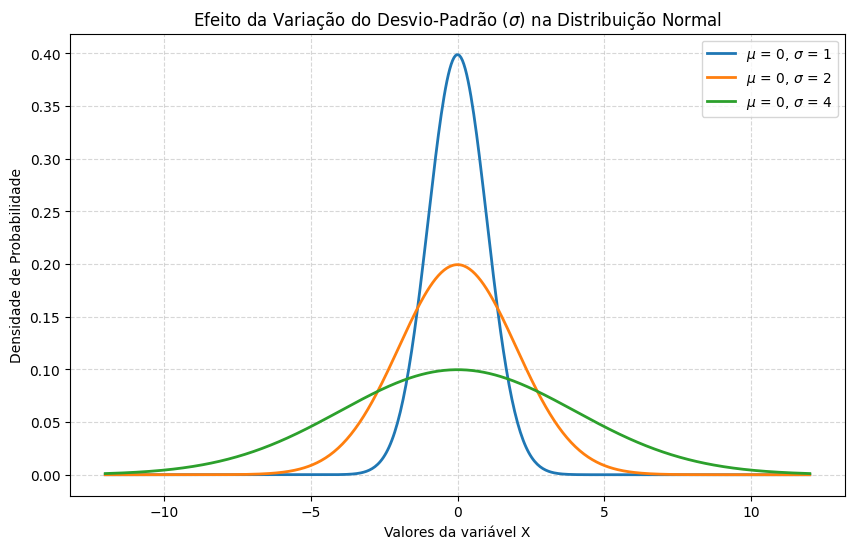

In [153]:
# Definição do intervalo do eixo x
x_disp = np.linspace(-12, 12, 500)

# Parâmetros
mu_fixo = 0
desvios = [1, 2, 4]

plt.figure(figsize=(10, 6))

for sig in desvios:
    y_pdf = stats.norm.pdf(x_disp, loc=mu_fixo, scale=sig)
    plt.plot(x_disp, y_pdf, label=fr'$\mu$ = {mu_fixo}, $\sigma$ = {sig}', linewidth=2)

plt.title(r'Efeito da Variação do Desvio-Padrão ($\sigma$) na Distribuição Normal')
plt.xlabel('Valores da variável X')
plt.ylabel('Densidade de Probabilidade')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

**Interpretação do gráfico de variação de desvio-padrão:**

Como a média $\mu$ foi mantida constante em zero, todas as três curvas têm seu pico centralizado exatamente na mesma coordenada $x = 0$. À medida que o desvio-padrão aumenta ($\sigma$ passa de 1 para 2, e depois para 4), a curva torna-se visivelmente mais espalhada (larga) e seu pico máximo se reduz de altura. Isso ocorre porque a área total sob a curva deve somar sempre $1.0$ (ou $100\%$); portanto, para espalhar os valores para as pontas, a altura do pico central é reduzida.

###Aplicação aos Dados Reais (Arroz Cammeo)

Vamos extrair os valores reais de área apenas para os grãos de variedade **Cammeo**, calcular suas estatísticas reais (média, desvio-padrão, mínimo e máximo) e plotar seu histograma de frequências reais juntamente com a curva Normal de melhor ajuste teórica.

Estatísticas Reais Observadas (Variedade Cammeo):
Média (mu): 14162.8920
Desvio-padrão (sigma): 1286.7705
Área Mínima: 9908
Área Máxima: 18913



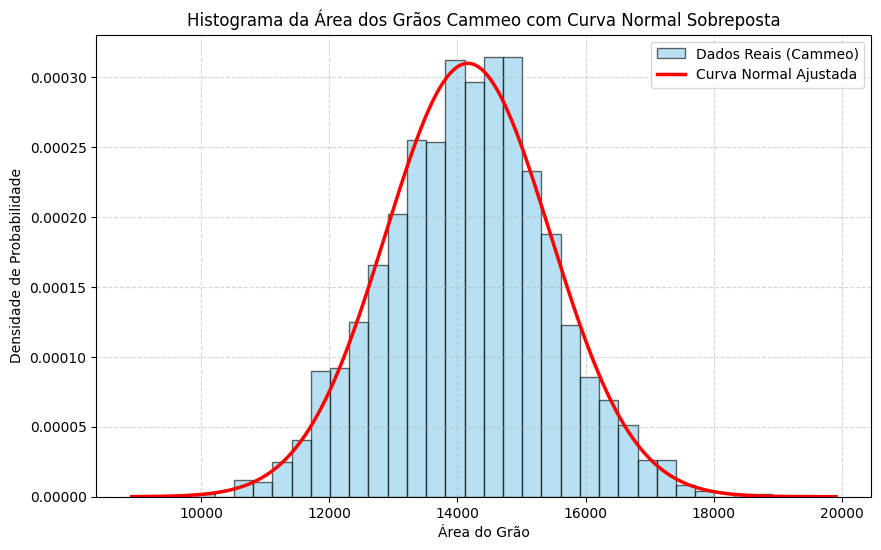

In [154]:
# Selecionando e criando a variável para os grãos Cammeo
area_cammeo = df[df["Class"] == "Cammeo"]["Area"]

# Cálculo das estatísticas reais descritivas
media_cammeo = area_cammeo.mean()
sigma_cammeo = area_cammeo.std()
min_cammeo = area_cammeo.min()
max_cammeo = area_cammeo.max()

print(f"Estatísticas Reais Observadas (Variedade Cammeo):")
print(f"Média (mu): {media_cammeo:.4f}")
print(f"Desvio-padrão (sigma): {sigma_cammeo:.4f}")
print(f"Área Mínima: {min_cammeo}")
print(f"Área Máxima: {max_cammeo}\n")

# Histograma com curva Normal sobreposta
plt.figure(figsize=(10, 6))

# Histograma dos dados reais normatizado (density=True)
plt.hist(area_cammeo, bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Dados Reais (Cammeo)')

# Curva normal teórica baseada nos dados calculados
x_plot = np.linspace(min_cammeo - 1000, max_cammeo + 1000, 500)
y_normal = stats.norm.pdf(x_plot, loc=media_cammeo, scale=sigma_cammeo)

plt.plot(x_plot, y_normal, color='red', linewidth=2.5, label='Curva Normal Ajustada')

plt.title('Histograma da Área dos Grãos Cammeo com Curva Normal Sobreposta')
plt.xlabel('Área do Grão')
plt.ylabel('Densidade de Probabilidade')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Discussão do Histograma:**

A plotagem e sobreposição visual da curva de densidade Gaussiana sobre o histograma empírico de dados reais é uma ferramenta qualitativa de diagnóstico para avaliar se a distribuição Normal descreve razoavelmente o padrão de distribuição da variável avaliada. Contudo, é essencial pontuar que a simples plotagem e semelhança visual não constituem uma prova estatística formal de que os dados seguem estritamente uma distribuição Normal.

### Probabilidades

Baseado nos valores que acabamos de obter na nossa amostra real de grãos Cammeo (com valores reais mínimos por volta de $9.900$ e máximos próximos a $18.900$), formularemos três questões contextualizadas de probabilidade com seus respectivos gráficos de áreas correspondentes sob a curva teórica.

#### Pergunta 1: Probabilidade Acumulada
* **Pergunta contextualizada:** "Qual é a probabilidade de selecionarmos aleatoriamente um grão de arroz da variedade Cammeo que apresente uma área de grão igual ou inferior a $13.000$ unidades de área?"

A probabilidade acumulada P(X <= 13000) é: 0.1831 (ou 18.31%)


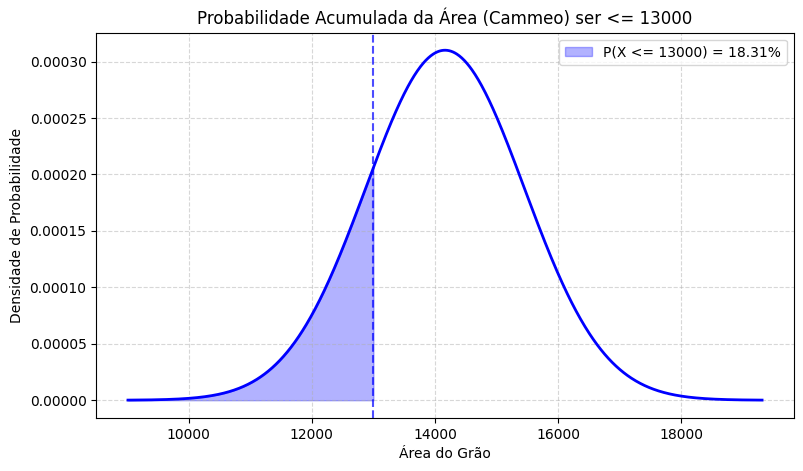

In [155]:
# 1. Probabilidade menor ou igual a 13000
limite_p1 = 13000
prob_p1 = stats.norm.cdf(limite_p1, loc=media_cammeo, scale=sigma_cammeo)
print(f"A probabilidade acumulada P(X <= 13000) é: {prob_p1:.4f} (ou {prob_p1 * 100:.2f}%)")

# Gráfico
x_prob = np.linspace(media_cammeo - 4 * sigma_cammeo, media_cammeo + 4 * sigma_cammeo, 1000)
y_prob = stats.norm.pdf(x_prob, loc=media_cammeo, scale=sigma_cammeo)

plt.figure(figsize=(9, 5))
plt.plot(x_prob, y_prob, color='blue', linewidth=2)

# Sombreamento
x_fill = np.linspace(media_cammeo - 4 * sigma_cammeo, limite_p1, 500)
y_fill = stats.norm.pdf(x_fill, loc=media_cammeo, scale=sigma_cammeo)
plt.fill_between(x_fill, y_fill, color='blue', alpha=0.3, label=f'P(X <= 13000) = {prob_p1*100:.2f}%')

plt.axvline(limite_p1, color='blue', linestyle='--', alpha=0.7)
plt.title('Probabilidade Acumulada da Área (Cammeo) ser <= 13000')
plt.xlabel('Área do Grão')
plt.ylabel('Densidade de Probabilidade')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### Pergunta 2: Probabilidade Entre Dois Valores
* **Pergunta contextualizada:** "Em processos industriais de classificação e seleção granulométrica de grãos, qual é a probabilidade de encontrarmos grãos de arroz Cammeo com área medindo no intervalo típico de classificação média, entre $13.500$ e $15.500$ unidades?"

A probabilidade P(13500 <= X <= 15500) é: 0.5474 (ou 54.74%)


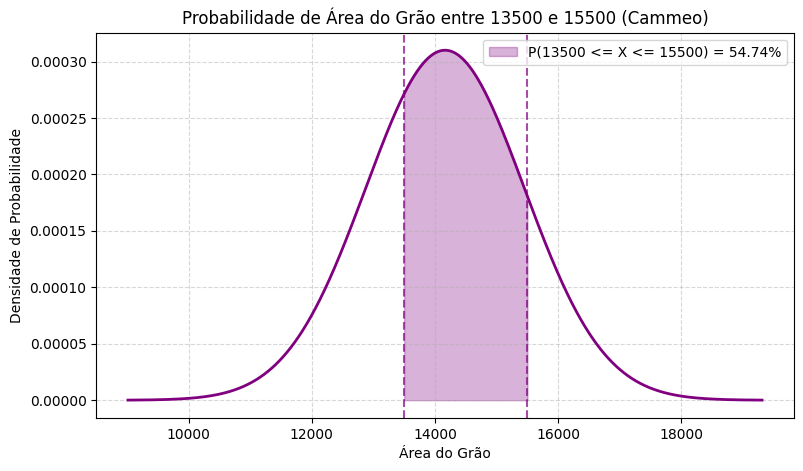

In [156]:
# 2. Probabilidade entre 13500 e 15500
limite_inf = 13500
limite_sup = 15500

prob_p2 = stats.norm.cdf(limite_sup, loc=media_cammeo, scale=sigma_cammeo) - stats.norm.cdf(limite_inf, loc=media_cammeo, scale=sigma_cammeo)
print(f"A probabilidade P(13500 <= X <= 15500) é: {prob_p2:.4f} (ou {prob_p2 * 100:.2f}%)")

# Gráfico
plt.figure(figsize=(9, 5))
plt.plot(x_prob, y_prob, color='purple', linewidth=2)

# Sombreamento
x_fill_p2 = np.linspace(limite_inf, limite_sup, 500)
y_fill_p2 = stats.norm.pdf(x_fill_p2, loc=media_cammeo, scale=sigma_cammeo)
plt.fill_between(x_fill_p2, y_fill_p2, color='purple', alpha=0.3, label=f'P(13500 <= X <= 15500) = {prob_p2*100:.2f}%')

plt.axvline(limite_inf, color='purple', linestyle='--', alpha=0.7)
plt.axvline(limite_sup, color='purple', linestyle='--', alpha=0.7)
plt.title('Probabilidade de Área do Grão entre 13500 e 15500 (Cammeo)')
plt.xlabel('Área do Grão')
plt.ylabel('Densidade de Probabilidade')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### Pergunta 3: Probabilidade Acima de um Valor (Função de Sobrevivência - Survival Function)
* **Pergunta contextualizada:** "Grãos excepcionalmente grandes podem ser considerados em um lote premium. Qual é a probabilidade de sortearmos ao acaso um grão de arroz Cammeo cuja área individual medida seja estritamente superior a $16.000$ unidades?"

A probabilidade de sobrevivência P(X > 16000) é: 0.0767 (ou 7.67%)


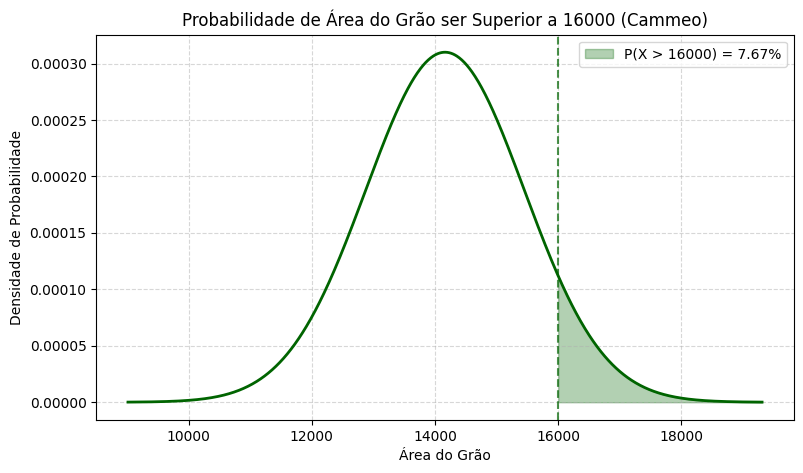

In [157]:
# 3. Probabilidade maior que 16000
limite_p3 = 16000
prob_p3 = stats.norm.sf(limite_p3, loc=media_cammeo, scale=sigma_cammeo)
print(f"A probabilidade de sobrevivência P(X > 16000) é: {prob_p3:.4f} (ou {prob_p3 * 100:.2f}%)")

# Gráfico
plt.figure(figsize=(9, 5))
plt.plot(x_prob, y_prob, color='darkgreen', linewidth=2)

# Sombreamento
x_fill_p3 = np.linspace(limite_p3, media_cammeo + 4 * sigma_cammeo, 500)
y_fill_p3 = stats.norm.pdf(x_fill_p3, loc=media_cammeo, scale=sigma_cammeo)
plt.fill_between(x_fill_p3, y_fill_p3, color='darkgreen', alpha=0.3, label=f'P(X > 16000) = {prob_p3*100:.2f}%')

plt.axvline(limite_p3, color='darkgreen', linestyle='--', alpha=0.7)
plt.title('Probabilidade de Área do Grão ser Superior a 16000 (Cammeo)')
plt.xlabel('Área do Grão')
plt.ylabel('Densidade de Probabilidade')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

###  Percentil

O percentil nos permite entender uma posição relativa dentro do lote ou da população analisada. Vamos calcular o **90º percentil** (P90) para a área de grãos Cammeo usando a função quantil (`ppf`).

In [158]:
# Calcular o percentil 90 (P90)
percentil_90 = stats.norm.ppf(0.90, loc=media_cammeo, scale=sigma_cammeo)
print(f"O 90º percentil (P90) calculado para a área do arroz Cammeo é: {percentil_90:.2f}")

O 90º percentil (P90) calculado para a área do arroz Cammeo é: 15811.95


**Interpretação prática no contexto de Ciência dos Alimentos:**

O 90º percentil com valor de aproximadamente **15.811,92** nos indica que **90%** dos grãos de arroz analisados da variedade Cammeo possuem área inferior ou igual a esse patamar. Por consequência, apenas os **10%** grãos maiores da colheita superam esse valor limite. Essa informação é vital para fins de controle de qualidade ou regulação e calibração de peneiras físicas e maquinários de separação física em indústrias de processamento e beneficiamento de grãos.

###  Condições e Limitações do Modelo

Ao fim desta análise teórica de modelagem, é fundamental destacar e discutir os limites estatísticos e práticos:

1. **Grandeza Modelada:** Estamos modelando uma característica geométrica física de um grão de arroz em nível individual (sua medição pontual de `Area`).
2. **Condições de Plausibilidade da Normal:** A distribuição Normal descreve bem variáveis contínuas físicas que resultam do efeito somado de múltiplos fatores genéticos e ambientais independentes (ex: solo, umidade, incidência solar e variações biológicas de desenvolvimento). Isso explica o formato simétrico e concentrado em torno da média.
3. **Presunção de Normalidade:** Como já mencionado, desenhar uma curva sob o histograma é apenas uma aproximação gráfica de visualização intuitiva de ajuste. Para assegurar formalmente e cientificamente que uma população segue uma distribuição teórica Gaussiana, é indispensável a condução de testes formais de hipóteses estatísticas como o teste de *Shapiro-Wilk* ou *Kolmogorov-Smirnov*.
4. **Limitação Fundamental:** Modelos matemáticos ideais aceitam qualquer valor no domínio real de $-\infty$ a $+\infty$. Contudo, na realidade biológica de grãos de arroz e alimentos, é biologicamente impossível existirem grãos com áreas menores ou iguais a zero. O modelo, portanto, funciona estritamente como aproximação teórica útil dentro de intervalos razoáveis ao redor da média encontrada.

## Distribuição t de Student

Nesta seção, analisaremos a **Distribuição t de Student**, investigando suas propriedades matemáticas, o papel crucial dos graus de liberdade e sua aplicação prática na inferência sobre a média amostral dos grãos Cammeo quando a variância populacional é desconhecida.

### Definição da Distribuição t de Student

A distribuição t de Student é uma distribuição de probabilidade contínua e simétrica, cuja forma se assemelha à distribuição Normal padrão, porém apresentando caudas mais pesadas (maior probabilidade de ocorrência de valores extremos).

**Situações de Utilização:**
Ela é empregada principalmente quando desejamos fazer inferências sobre a média de uma população a partir de uma amostra, mas a variância ou desvio-padrão populacional ($\sigma^2$ ou $\sigma$) é desconhecido, sendo necessário estimá-lo por meio do desvio-padrão amostral ($S$). Isso é extremamente comum em Ciência dos Alimentos, onde dispomos de poucas repetições experimentais devido a custos e tempo.

**Função Densidade de Probabilidade (FDP):**
A função densidade de probabilidade para a variável $t$ é dada por:

$$f(t) = \frac{\Gamma\left(\frac{\nu + 1}{2}\right)}{\sqrt{\nu\pi} \; \Gamma\left(\frac{\nu}{2}\right)} \left(1 + \frac{t^2}{\nu}\right)^{-\frac{\nu+1}{2}}$$

Onde:
* $t$: representa a estatística t padronizada.
* $\nu$ (nu): representa o número de **graus de liberdade** (geralmente determinado por $\nu = n - 1$, onde $n$ é o tamanho da amostra).
* $\Gamma$ (gama): representa a função Gama, uma generalização do fatorial para números reais.
* $\pi$ (pi): a constante matemática aproximada em $3,14159$.

**Parâmetro de Graus de Liberdade ($\nu$):**
* **Valores Admissíveis:** O parâmetro deve ser estritamente positivo e real ($\nu > 0$), sendo comumente um número inteiro maior ou igual a 1.
* **Efeito na curva:** Quanto menor o valor de $\nu$, mais achatada será a distribuição e mais espessas serão as suas caudas. Isso reflete a maior incerteza associada a amostras pequenas.
* **Aproximação à Normal:** Conforme os graus de liberdade aumentam ($\nu \to \infty$), a estimativa de $S$ se aproxima do verdadeiro desvio-padrão populacional $\sigma$. Consequentemente, a curva t de Student converge para a curva da Distribuição Normal padrão ($Z$).

**Referências Teóricas:**
* Morettin, P. A., & Bussab, W. O. (2017). *Estatística Básica* (9ª ed.). Saraiva.
* Documentação Oficial do Módulo SciPy Stats: [scipy.stats.t](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.t.html).

### Diferenciar Medição Individual e Estatística Amostral

É fundamental notar que nesta seção a distribuição t **não** modela diretamente as dimensões de um grão isolado. Ao invés disso, ela é usada para estudar a variabilidade e a confiança da **média amostral** calculada a partir de um grupo de grãos.

Para isso, utilizamos a estatística de teste $T$:

$$T = \frac{\bar{X} - \mu}{\frac{S}{\sqrt{n}}}$$

Onde:
* $\bar{X}$: média amostral obtida.
* $\mu$: média populacional de referência.
* $S$: desvio-padrão amostral obtido.
* $n$: número de grãos coletados na amostra.
* $\frac{S}{\sqrt{n}}$: erro-padrão da média, indicando a variação esperada para as médias amostrais.
* Graus de Liberdade (gl): definidos como $\nu = n - 1$.

### Gráfico Variando os Graus de Liberdade

Abaixo, vamos gerar um gráfico comparativo contendo a densidade probabilística da distribuição t com diferentes graus de liberdade ($\nu = 2, 5, 10, 30$) e a curva da distribuição Normal Padrão para referência.

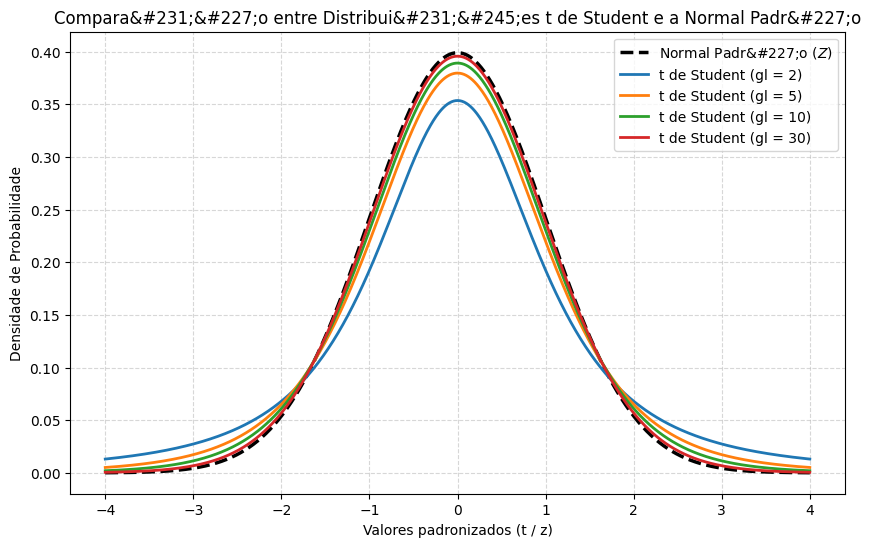

In [159]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

x_t = np.linspace(-4, 4, 1000)

plt.figure(figsize=(10, 6))

# Curva Normal Padr&#227;o (Z)
y_z = stats.norm.pdf(x_t, loc=0, scale=1)
plt.plot(x_t, y_z, label='Normal Padr&#227;o ($Z$)', color='black', linestyle='--', linewidth=2.5)

# Curvas t com diferentes graus de liberdade
graus_liberdade = [2, 5, 10, 30]
for gl in graus_liberdade:
    y_t = stats.t.pdf(x_t, df=gl)
    plt.plot(x_t, y_t, label=f't de Student (gl = {gl})', linewidth=2)

plt.title('Compara&#231;&#227;o entre Distribui&#231;&#245;es t de Student e a Normal Padr&#227;o')
plt.xlabel('Valores padronizados (t / z)')
plt.ylabel('Densidade de Probabilidade')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

**Interpretação do gráfico:**
* Quando os graus de liberdade são extremamente pequenos (como $\text{gl} = 2$), a curva t apresenta pico visivelmente menor e caudas muito mais elevadas em relação à Normal Padrão.
* Conforme o valor do grau de liberdade aumenta, a curva t vai gradativamente se estreitando, seu pico máximo se eleva e as caudas diminuem. Com $\text{gl} = 30$, a diferença em relação à Normal padrão torna-se praticamente imperceptível ao olho nu.

### Aplicação aos Dados Reais (Amostragem)

Vamos isolar a subpopulação Cammeo e extrair uma amostra probabilística de tamanho $n = 30$ para simularmos um experimento típico de laboratório de alimentos. Para fins didáticos, tratamos a totalidade dos grãos Cammeo disponíveis na base ($1.630$ unidades) como a nossa população de referência.

In [160]:
# Filtrando e extraindo a popula&#231;&#227;o Cammeo
populacao_cammeo = df[df["Class"] == "Cammeo"]["Area"]
mu_populacional = populacao_cammeo.mean()

# Extrair amostra com semente aleat&#243;ria para fins de reprodutibilidade
tamanho_amostra = 30
amostra_cammeo = populacao_cammeo.sample(n=tamanho_amostra, random_state=42)

# Estat&#237;sticas amostrais
media_amostral = amostra_cammeo.mean()
desvio_padrao_amostral = amostra_cammeo.std()
erro_padrao = desvio_padrao_amostral / np.sqrt(tamanho_amostra)
graus_lib = tamanho_amostra - 1

print(f"--- RESULTADOS DA AMOSTRAGEM COMPILADOS ---")
print(f"M&#233;dia Populacional de Refer&#234;ncia (mu): {mu_populacional:.4f}")
print(f"Tamanho da Amostra (n): {tamanho_amostra}")
print(f"M&#233;dia Amostral (X_barra): {media_amostral:.4f}")
print(f"Desvio-padr&#227;o Amostral (S): {desvio_padrao_amostral:.4f}")
print(f"Erro-padr&#227;o Estimado: {erro_padrao:.4f}")
print(f"Graus de Liberdade (gl): {graus_lib}")

--- RESULTADOS DA AMOSTRAGEM COMPILADOS ---
M&#233;dia Populacional de Refer&#234;ncia (mu): 14162.8920
Tamanho da Amostra (n): 30
M&#233;dia Amostral (X_barra): 14231.1667
Desvio-padr&#227;o Amostral (S): 1250.5771
Erro-padr&#227;o Estimado: 228.3231
Graus de Liberdade (gl): 29


### Probabilidades com a Distribuição t de Student

Empregando os parâmetros extraídos da amostra real, vamos responder três perguntas comuns no controle e garantia de qualidade físico-química de alimentos.

#### Pergunta 1: Probabilidade Acumulada Esquerda
* **Pergunta contextualizada:** "Se colhermos uma nova amostra aleatória de 30 grãos do lote, qual é a probabilidade de encontrarmos um valor de t padronizado menor ou igual a $-1,5$ (o que indica que a média amostral ficaria consideravelmente abaixo da expectativa média real)?"

P(T <= -1.5) = 0.0722 (ou 7.22%)



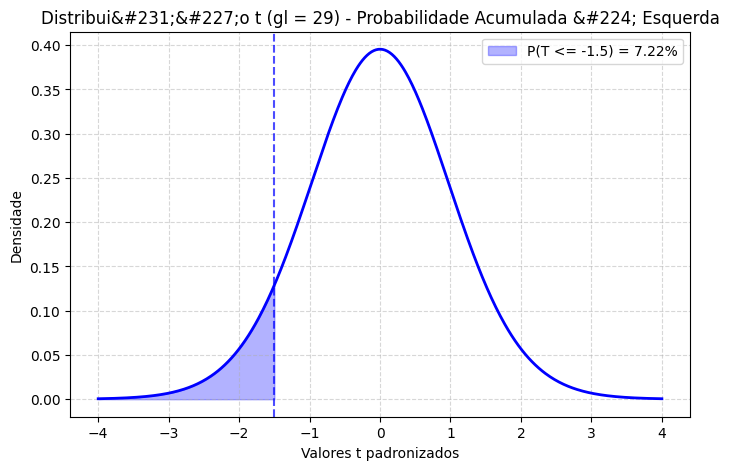

In [161]:
# 1. Probabilidade acumulada P(T <= -1.5)
t0_p1 = -1.5
prob_acumulada_t = stats.t.cdf(t0_p1, df=graus_lib)
print(f"P(T <= -1.5) = {prob_acumulada_t:.4f} (ou {prob_acumulada_t * 100:.2f}%)\n")

# Gr&#225;fico
x_t_axis = np.linspace(-4, 4, 500)
y_t_axis = stats.t.pdf(x_t_axis, df=graus_lib)

plt.figure(figsize=(8, 5))
plt.plot(x_t_axis, y_t_axis, color='blue', linewidth=2)
x_shading = np.linspace(-4, t0_p1, 200)
plt.fill_between(x_shading, stats.t.pdf(x_shading, df=graus_lib), color='blue', alpha=0.3, label=f'P(T <= {t0_p1}) = {prob_acumulada_t*100:.2f}%')
plt.axvline(t0_p1, color='blue', linestyle='--', alpha=0.7)

plt.title(f'Distribui&#231;&#227;o t (gl = {graus_lib}) - Probabilidade Acumulada &#224; Esquerda')
plt.xlabel('Valores t padronizados')
plt.ylabel('Densidade')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### Pergunta 2: Probabilidade Entre Dois Limites
* **Pergunta contextualizada:** "Qual a probabilidade do valor t padronizado da nossa média amostral cair no intervalo simétrico central de controle de aceitação técnica de $-1,2$ a $+1,2$?"

P(-1.2 <= T <= 1.2) = 0.7601 (ou 76.01%)



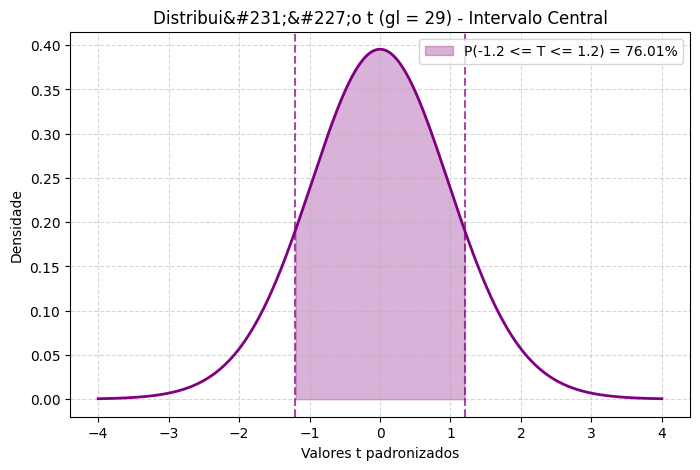

In [162]:
# 2. Probabilidade entre -1.2 e 1.2
t_inf = -1.2
t_sup = 1.2
prob_intervalo_t = stats.t.cdf(t_sup, df=graus_lib) - stats.t.cdf(t_inf, df=graus_lib)
print(f"P(-1.2 <= T <= 1.2) = {prob_intervalo_t:.4f} (ou {prob_intervalo_t * 100:.2f}%)\n")

# Gr&#225;fico
plt.figure(figsize=(8, 5))
plt.plot(x_t_axis, y_t_axis, color='purple', linewidth=2)
x_shading_p2 = np.linspace(t_inf, t_sup, 200)
plt.fill_between(x_shading_p2, stats.t.pdf(x_shading_p2, df=graus_lib), color='purple', alpha=0.3, label=f'P({t_inf} <= T <= {t_sup}) = {prob_intervalo_t*100:.2f}%')
plt.axvline(t_inf, color='purple', linestyle='--', alpha=0.7)
plt.axvline(t_sup, color='purple', linestyle='--', alpha=0.7)

plt.title(f'Distribui&#231;&#227;o t (gl = {graus_lib}) - Intervalo Central')
plt.xlabel('Valores t padronizados')
plt.ylabel('Densidade')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### Pergunta 3: Probabilidade de Sobrevivência à Direita
* **Pergunta contextualizada:** "Ao extrair as amostras físicas dos lotes, qual é a probabilidade teórica do valor t padronizado ultrapassar $+1,8$ desvios, o que representaria amostras com médias de área muito acima do padrão esperado?"

P(T > 1.8) = 0.0411 (ou 4.11%)



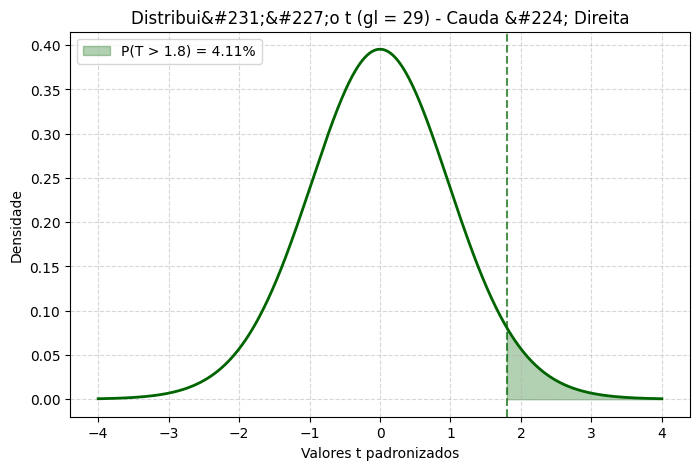

In [163]:
# 3. Probabilidade maior que 1.8
t0_p3 = 1.8
prob_direita_t = stats.t.sf(t0_p3, df=graus_lib)
print(f"P(T > 1.8) = {prob_direita_t:.4f} (ou {prob_direita_t * 100:.2f}%)\n")

# Gr&#225;fico
plt.figure(figsize=(8, 5))
plt.plot(x_t_axis, y_t_axis, color='darkgreen', linewidth=2)
x_shading_p3 = np.linspace(t0_p3, 4, 200)
plt.fill_between(x_shading_p3, stats.t.pdf(x_shading_p3, df=graus_lib), color='darkgreen', alpha=0.3, label=f'P(T > {t0_p3}) = {prob_direita_t*100:.2f}%')
plt.axvline(t0_p3, color='darkgreen', linestyle='--', alpha=0.7)

plt.title(f'Distribui&#231;&#227;o t (gl = {graus_lib}) - Cauda &#224; Direita')
plt.xlabel('Valores t padronizados')
plt.ylabel('Densidade')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Percentil

Faremos o cálculo do **percentil 95%** ($T_{0.95}$) da nossa curva t de Student, correspondente aos nossos graus de liberdade da amostra real ($gl = 29$).

In [164]:
# Calcular o percentil 95%
percentil_95_t = stats.t.ppf(0.95, df=graus_lib)
print(f"O 95&#186; percentil (T0.95) calculado para gl={graus_lib} &#233;: {percentil_95_t:.4f}")

O 95&#186; percentil (T0.95) calculado para gl=29 &#233;: 1.6991


**Significado do valor do percentil no contexto amostral:**

O percentil 95% indica o limite crítico abaixo do qual estão acumulados $95\%$ de todas as possíveis estatísticas $T$ das amostras experimentais. Em processos de inspeção industrial, isso estabelece um valor crítico de aceitabilidade: há apenas $5\%$ de chance de obtermos por acaso uma média de amostra cuja estatística $T$ calculada ultrapasse esse patamar crítico.

### Interpretação no Contexto dos Dados

* **Incerteza da Média:** Ao extrair médias amostrais, temos um erro natural de estimação associado. A distribuição t de Student quantifies essa flutuação amostral.
* **Diferença Fundamental:** A t modela a incerteza estatística da **média amostral**, e não a distribuição geométrica física individual da área dos grãos.
* **Impacto da Amostra:** Quanto menor o tamanho da amostra física ($n$), maior será a flutuação e incerteza sobre o verdadeiro valor da variância do arroz. Dessa forma, as caudas mais cheias da t refletem e compensam essa falta de precisão.

### Condições e Limitações

* **Independência:** Para que a modelagem via distribuição t seja teoricamente válida, os grãos de arroz de uma mesma amostra devem ser selecionados independentemente no lote.
* **Normalidade:** Em amostras pequenas ($n < 30$), assume-se que a variável `Area` na população original tenha formato aproximadamente Normal. Se a população real apresentar uma assimetria severa, a aproximação t perde rigor científico.
* **Incerteza Estimada:** A distribuição assume que conhecemos somente a estimativa do desvio-padrão amostral ($S$).
* **Aproximação Didática:** Consideramos o total de $1.630$ observadas na colheita como a 'população completa' de referência de grãos Cammeo apenas para permitir calcularmos um $\mu$ exato e compreendermos a teoria de amostragem na prática didática acadêmica.

##  Distribuição Qui-quadrado ($\chi^2$)

Nesta seção, estudaremos a **Distribuição Qui-quadrado** ($\chi^2$), analisando suas propriedades matemáticas, comportamento geométrico e como ela é utilizada na modelagem da variabilidade estatística associada ao controle de uniformidade física em lotes de grãos de arroz.

###Definição da Distribuição Qui-quadrado

A distribuição Qui-quadrado é uma distribuição de probabilidade contínua de extrema importância na inferência estatística, sendo amplamente aplicada em testes de aderência, testes de independência em tabelas de contingência e na modelagem de variâncias amostrais.

**Principais Características:**
1. **Contínua:** A variável de interesse assume valores em um domínio contínuo.
2. **Valores Não Negativos:** Como a estatística é fundamentada em somas de termos elevados ao quadrado, a variável aleatória Qui-quadrado assume apenas valores reais não negativos ($0 \le \chi^2 < \infty$).
3. **Assimetria Positiva:** A distribuição é tipicamente assimétrica à direita. Para poucos graus de liberdade, essa assimetria é bastante acentuada; à medida que o parâmetro de graus de liberdade aumenta, a curva se torna progressivamente mais simétrica e próxima de uma distribuição Normal.

**Função Densidade de Probabilidade (FDP):**
A densidade de probabilidade de uma variável aleatória $X$ com distribuição Qui-quadrado e $\nu$ graus de liberdade é descrita pela seguinte equação para $x > 0$:

$$f(x) = \frac{1}{2^{\frac{\nu}{2}} \Gamma\left(\frac{\nu}{2}\right)} x^{\left(\frac{\nu}{2}\right) - 1} e^{-\frac{x}{2}}$$

Onde:
* $x$: representa o valor da estatística Qui-quadrado.
* $\nu$ (nu): representa o parâmetro de **graus de liberdade**.
* $\Gamma$ (Gama): representa a função matemática Gama, que estende o conceito de fatorial para números reais.
* $e$: constante neperiana aproximada em $2,71828$.

**Parâmetro de Graus de Liberdade ($\nu$):**
* **Valores Admissíveis:** O parâmetro de graus de liberdade deve ser um número inteiro estritamente positivo ($\nu \in \mathbb{Z}^+$), ou seja, $\nu \ge 1$.
* **Efeito Geométrico na Curva:** O valor de $\nu$ define completamente a forma da distribuição. Para valores muito baixos (como $\nu = 2$ ou $\nu = 5$), o pico de densidade está muito próximo de zero e a curva cai de forma abrupta à direita. À medida que $\nu$ cresce, o ponto de pico se desloca para a direita (próximo ao valor de $\nu$) e a variabilidade (dispersão) horizontal aumenta, achatando a curva enquanto esta adquire simetria.

**Referências Teóricas:**
* Bussab, W. O., & Morettin, P. A. (2017). *Estatística Básica* (9ª ed.). Saraiva.
* Documentação Oficial do Módulo SciPy Stats: [scipy.stats.chi2](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2.html).

### 6.2. Relação com a Variância

É fundamental ressaltar que a distribuição Qui-quadrado **não** será utilizada para modelar a área física direta de cada grão de arroz individual de forma isolada. Em vez disso, ela é empregada para modelar e estudar a distribuição amostral de uma estatística relacionada com a **variabilidade (variância)** observada dentro de um lote de grãos.

Quando coletamos uma amostra aleatória de tamanho $n$ de uma população com distribuição Normal de variância $\sigma^2$, a variância calculada na amostra ($S^2$) flutuará devido ao erro de amostragem. A relação matemática exata que descreve o comportamento dessa flutuação é dada pela estatística de teste Qui-quadrado:

$$\chi^2 = \frac{(n-1)S^2}{\sigma^2}$$

Onde:
* $n$: representa o tamanho da amostra coletada (número de grãos observados no experimento).
* $S^2$: representa a variância amostral obtida a partir das medições físicas da amostra.
* $\sigma^2$: representa a variância populacional real de referência para a variável de interesse.
* Graus de Liberdade ($\nu$): definidos como $\nu = n - 1$.

Sob a premissa de que a característica física de interesse (no nosso caso, a `Area` dos grãos) segue uma distribuição Normal na população de origem, a estatística de teste descrita acima segue exatamente uma distribuição teórica Qui-quadrado com $\nu = n - 1$ graus de liberdade.

###  Gráfico Variando os Graus de Liberdade

Abaixo, plotamos as curvas de densidade de probabilidade teóricas para diferentes graus de liberdade ($\nu = 2, 5, 10, 30$) para visualizar como o formato e a dispersão geométrica da Qui-quadrado se comportam.

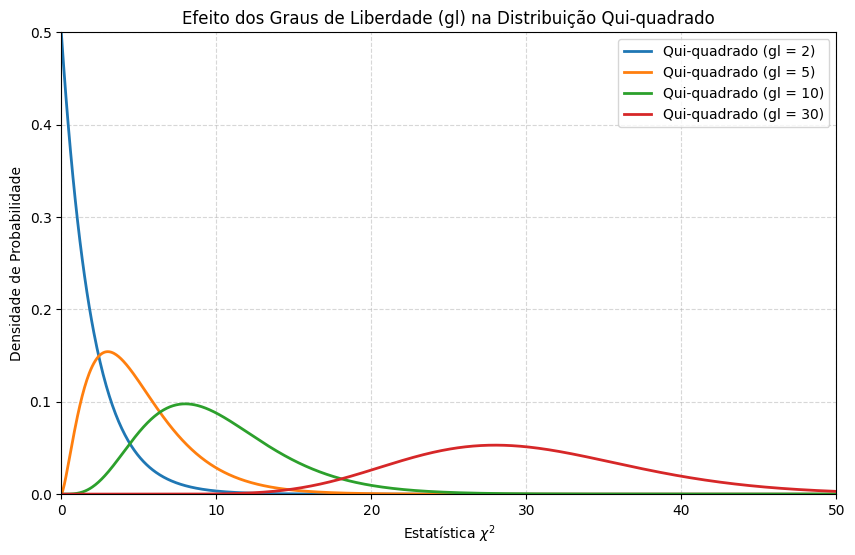

In [165]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Definição do intervalo do eixo x para exibição das densidades
x_chi = np.linspace(0, 50, 1000)

plt.figure(figsize=(10, 6))

# Curvas para diferentes graus de liberdade
graus_lib_chi = [2, 5, 10, 30]
for gl_v in graus_lib_chi:
    y_chi = stats.chi2.pdf(x_chi, df=gl_v)
    plt.plot(x_chi, y_chi, label=f'Qui-quadrado (gl = {gl_v})', linewidth=2)

plt.title('Efeito dos Graus de Liberdade (gl) na Distribuição Qui-quadrado')
plt.xlabel(r'Estatística $\chi^2$')
plt.ylabel('Densidade de Probabilidade')
plt.xlim(0, 50)
plt.ylim(0, 0.5)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

**Interpretação prática do gráfico de variação dos graus de liberdade:**

* **Assimetria com poucos graus de liberdade:** Com poucos graus de liberdade ($\nu = 2$ ou $\nu = 5$), a distribuição apresenta forte assimetria à direita, com os dados acumulados próximos de zero e uma cauda que se estende de forma alongada.
* **Deslocamento e espalhamento:** Conforme o número de graus de liberdade aumenta, o ponto de maior densidade (pico) se desloca para a direita e a curva se espalha mais ao longo do eixo horizontal, refletindo um aumento natural na variabilidade acumulada do modelo.
* **Convergência para a Simetria:** Para $\nu = 30$, a assimetria característica é consideravelmente atenuada e a curva assume um perfil que visualmente se aproxima da forma em sino da distribuição Normal, ilustrando o teorema do limite central para somas de variáveis independentes.

### 6.4. Aplicação aos Dados Reais (Arroz Cammeo)

Para demonstrar de forma prática a teoria, vamos utilizar o banco de dados real. Isolaremos a subpopulação de grãos de arroz **Cammeo** e extrairemos uma amostra aleatória de tamanho $n = 30$ para simularmos um teste laboratorial de variabilidade granulométrica.

Para fins puramente didáticos, assumiremos que a variância calculada a partir de todos os grãos Cammeo contidos no banco de dados ($1.630$ grãos) representa a variância populacional real de referência ($\sigma^2$).

In [166]:
# 1. Selecionar os grãos da variedade Cammeo
area_cammeo = df[df["Class"] == "Cammeo"]["Area"]

# 2. Calcular a variância populacional de referência (didática)
variancia_populacional_cammeo = area_cammeo.var(ddof=0)

# 3. Extrair amostra aleatória (n = 30)
tamanho_amostra_chi = 30
amostra_chi_cammeo = area_cammeo.sample(n=tamanho_amostra_chi, random_state=42)

# 4. Calcular estatísticas amostrais
variancia_amostral_cammeo = amostra_chi_cammeo.var(ddof=1)
gl_chi = tamanho_amostra_chi - 1

# 5. Calcular a estatística Qui-quadrado observada para a amostra
estatistica_chi_calculada = (gl_chi * variancia_amostral_cammeo) / variancia_populacional_cammeo

print("--- RESULTADOS DOS CÁLCULOS COM DADOS REAIS ---")
print(f"Variância Populacional de Referência (sigma^2): {variancia_populacional_cammeo:.2f}")
print(f"Variância Amostral Calculada (S^2): {variancia_amostral_cammeo:.2f}")
print(f"Tamanho da Amostra (n): {tamanho_amostra_chi}")
print(f"Graus de Liberdade (gl): {gl_chi}")
print(f"Estatística Qui-quadrado Calculada: {estatistica_chi_calculada:.4f}")

--- RESULTADOS DOS CÁLCULOS COM DADOS REAIS ---
Variância Populacional de Referência (sigma^2): 1654762.56
Variância Amostral Calculada (S^2): 1563943.18
Tamanho da Amostra (n): 30
Graus de Liberdade (gl): 29
Estatística Qui-quadrado Calculada: 27.4084


### Probabilidades com a Distribuição Qui-quadrado

Com base nos parâmetros populacionais e amostrais da área dos grãos Cammeo, formularemos três perguntas contextualizadas para calcular probabilidades associadas à estatística Qui-quadrado ($\nu = 29$).

#### Pergunta 1: Probabilidade Acumulada à Esquerda
* **Pergunta contextualizada:** "Ao selecionarmos uma amostra aleatória de 30 grãos de arroz Cammeo, qual é a probabilidade de obtermos uma variância amostral tão homogênea que faça a nossa estatística Qui-quadrado calculada ser menor ou igual a $18,0$ unidades?"

P(Chi-quadrado <= 18.0) = 0.0557 (ou 5.57%)


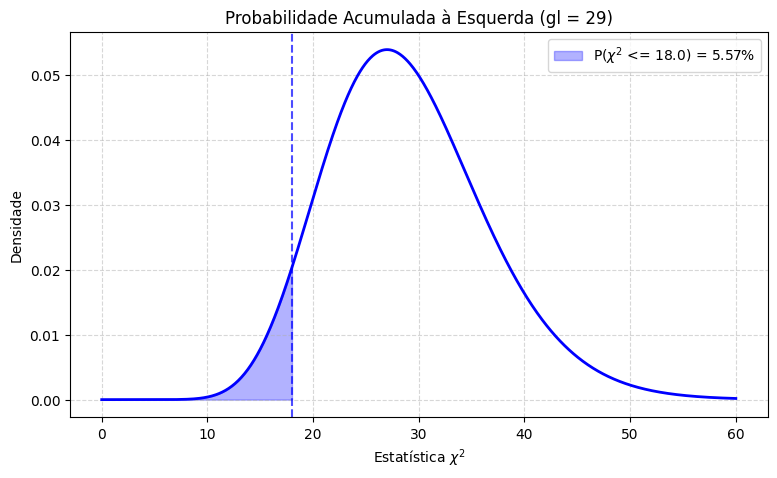

In [167]:
# 1. Probabilidade acumulada P(X^2 <= 18.0)
limite_chi_p1 = 18.0
prob_p1_chi = stats.chi2.cdf(limite_chi_p1, df=gl_chi)
print(f"P(Chi-quadrado <= 18.0) = {prob_p1_chi:.4f} (ou {prob_p1_chi * 100:.2f}%)")

# Eixo x para os gráficos de probabilidade
x_prob_chi = np.linspace(0, 60, 1000)
y_prob_chi = stats.chi2.pdf(x_prob_chi, df=gl_chi)

# Gráfico
plt.figure(figsize=(9, 5))
plt.plot(x_prob_chi, y_prob_chi, color='blue', linewidth=2)

# Sombreamento
x_fill_chi1 = np.linspace(0, limite_chi_p1, 500)
y_fill_chi1 = stats.chi2.pdf(x_fill_chi1, df=gl_chi)
plt.fill_between(x_fill_chi1, y_fill_chi1, color='blue', alpha=0.3, label=rf'P($\chi^2$ <= 18.0) = {prob_p1_chi*100:.2f}%')

plt.axvline(limite_chi_p1, color='blue', linestyle='--', alpha=0.7)
plt.title(f'Probabilidade Acumulada à Esquerda (gl = {gl_chi})')
plt.xlabel(r'Estatística $\chi^2$')
plt.ylabel('Densidade')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### Pergunta 2: Probabilidade no Intervalo Central
* **Pergunta contextualizada:** "Em inspeções industriais para a padronização granulométrica, qual é a probabilidade do lote amostrado de 30 grãos apresentar uma variabilidade de área intermediária, de modo que a estatística Qui-quadrado correspondente caia dentro do intervalo representativo central de $20,0$ a $38,0$ unidades?"

P(20.0 <= Chi-quadrado <= 38.0) = 0.7706 (ou 77.06%)


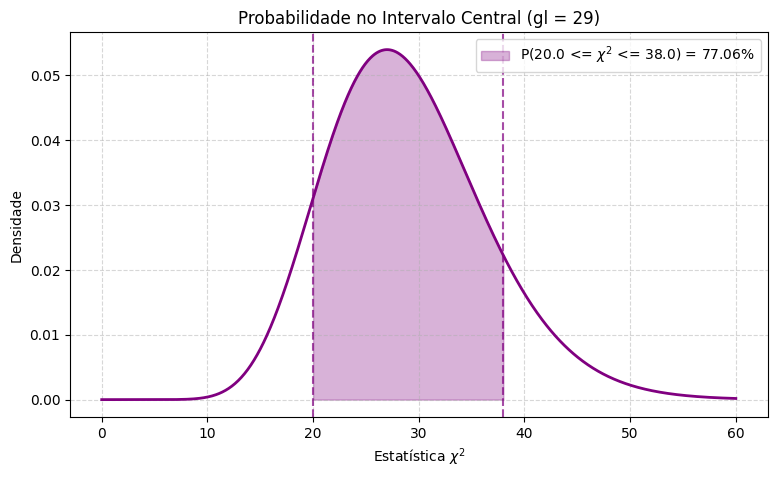

In [168]:
# 2. Probabilidade entre 20.0 e 38.0
limite_chi_inf = 20.0
limite_chi_sup = 38.0

prob_p2_chi = stats.chi2.cdf(limite_chi_sup, df=gl_chi) - stats.chi2.cdf(limite_chi_inf, df=gl_chi)
print(f"P(20.0 <= Chi-quadrado <= 38.0) = {prob_p2_chi:.4f} (ou {prob_p2_chi * 100:.2f}%)")

# Gráfico
plt.figure(figsize=(9, 5))
plt.plot(x_prob_chi, y_prob_chi, color='purple', linewidth=2)

# Sombreamento
x_fill_chi2 = np.linspace(limite_chi_inf, limite_chi_sup, 500)
y_fill_chi2 = stats.chi2.pdf(x_fill_chi2, df=gl_chi)
plt.fill_between(x_fill_chi2, y_fill_chi2, color='purple', alpha=0.3, label=rf'P(20.0 <= $\chi^2$ <= 38.0) = {prob_p2_chi*100:.2f}%')

plt.axvline(limite_chi_inf, color='purple', linestyle='--', alpha=0.7)
plt.axvline(limite_chi_sup, color='purple', linestyle='--', alpha=0.7)
plt.title(f'Probabilidade no Intervalo Central (gl = {gl_chi})')
plt.xlabel(r'Estatística $\chi^2$')
plt.ylabel('Densidade')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### Pergunta 3: Probabilidade na Cauda Direita (Sobrevivência)
* **Pergunta contextualizada:** "Um alto valor da estatística Qui-quadrado aponta para uma dispersão de área excessiva, o que pode indicar falhas na classificação dos grãos. Qual é a probabilidade teórica de selecionarmos uma amostra cuja estatística Qui-quadrado calculada seja estritamente superior a $42,0$ unidades?"

P(Chi-quadrado > 42.0) = 0.0562 (ou 5.62%)


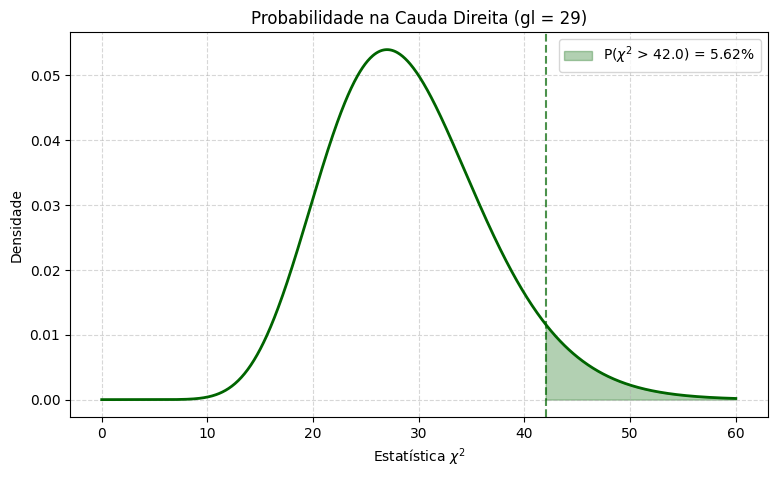

In [169]:
# 3. Probabilidade maior que 42.0 (Survival Function)
limite_chi_p3 = 42.0
prob_p3_chi = stats.chi2.sf(limite_chi_p3, df=gl_chi)
print(f"P(Chi-quadrado > 42.0) = {prob_p3_chi:.4f} (ou {prob_p3_chi * 100:.2f}%)")

# Gráfico
plt.figure(figsize=(9, 5))
plt.plot(x_prob_chi, y_prob_chi, color='darkgreen', linewidth=2)

# Sombreamento
x_fill_chi3 = np.linspace(limite_chi_p3, 60, 500)
y_fill_chi3 = stats.chi2.pdf(x_fill_chi3, df=gl_chi)
plt.fill_between(x_fill_chi3, y_fill_chi3, color='darkgreen', alpha=0.3, label=rf'P($\chi^2$ > 42.0) = {prob_p3_chi*100:.2f}%')

plt.axvline(limite_chi_p3, color='darkgreen', linestyle='--', alpha=0.7)
plt.title(f'Probabilidade na Cauda Direita (gl = {gl_chi})')
plt.xlabel(r'Estatística $\chi^2$')
plt.ylabel('Densidade')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

###  Percentil

O percentil nos permite delimitar intervalos e pontos de corte críticos para o monitoramento da uniformidade. Abaixo, vamos calcular o **95º percentil** (P95) para a distribuição Qui-quadrado associada a amostras de $n=30$ ($\nu=29$).

In [170]:
# Calcular o percentil 95 (P95)
percentil_95_chi = stats.chi2.ppf(0.95, df=gl_chi)
print(f"O 95º percentil (P95) calculado para gl={gl_chi} é: {percentil_95_chi:.4f}")

O 95º percentil (P95) calculado para gl=29 é: 42.5570


**Interpretação prática no contexto da Ciência de Alimentos:**

O valor do 95º percentil ($\approx 42,56$) indica que em $95\%$ das amostras extraídas desse lote, o valor da estatística $\chi^2$ associada à variância amostral será menor ou igual a esse limite crítico. Consequentemente, apenas em $5\%$ dos casos encontraremos amostras aleatórias cuja flutuação de amostragem resulte em um desvio estatístico de variabilidade tão elevado que ultrapasse este patamar. Trata-se de uma métrica de controle de qualidade para definir se um lote de beneficiamento de arroz está operando sob os níveis aceitáveis de padronização granulométrica.

### 6.7. Interpretação no Contexto dos Dados

* **Grandeza Modelada:** É essencial destacar que a quantidade física modelada aqui não é a área de um único grão em si, mas sim a **variância amostral** ($S^2$) associada a um grupo amostrado, escalonada pela variância populacional de referência.
* **Significado Físico-Estatístico:** Valores muito distantes e posicionados nas extremidades da curva Qui-quadrado indicam variâncias amostrais significativamente discrepantes do comportamento populacional esperado. Um valor de $\chi^2$ na extrema esquerda indica uma amostra artificialmente homogênea, ao passo que um valor de $\chi^2$ na cauda direita sinaliza um lote com severo desvio de uniformidade.
* **Área sob a Curva:** A integral de uma determinada região sob a curva Qui-quadrado corresponde diretamente à probabilidade matemática da estatística da amostra se situar dentro dessa faixa de dispersão.

### Condições e Limitações

1. **Pressuposto de Independência:** O modelo Qui-quadrado assume que cada grão da amostra de tamanho $n=30$ tenha sido colhido de forma totalmente independente e livre de viés de seleção no lote.
2. **Exigência de Normalidade da Variável Original:** A propriedade matemática de que $\frac{(n-1)S^2}{\sigma^2}$ segue exatamente uma distribuição Qui-quadrado depende estritamente de que a variável original de interesse (`Area`) siga uma distribuição perfeitamente Normal na população. Se a população real de origem for altamente assimétrica ou bimodal, a distribuição de $S^2$ sofrerá desvios teóricos que reduzem a precisão probabilística do modelo Qui-quadrado.
3. **Sensibilidade do Modelo:** Testes de variabilidade são sensíveis a desvios no pressuposto de normalidade da população. Pequenas assimetrias presentes na distribuição física dos grãos podem acarretar discrepâncias importantes nas caudas da distribuição teórica Qui-quadrado.
4. **Limitação Metodológica Didática:** Empregar o conjunto completo de grãos *Cammeo* da base ($1.630$ observações) como a 'população completa' é uma convenção didática que nos permitiu fixar um valor populacional de variância $\sigma^2$ exato, permitindo estudar os conceitos sem as incertezas reais de desvio-padrão de variâncias populacionais desconhecidas.

## Distribuição F de Fisher

Nesta seção, estudaremos a **Distribuição F de Fisher**, também conhecida como distribuição F de Snedecor. Ela será utilizada para analisar a razão entre variâncias e, neste trabalho, permitirá comparar a variabilidade da variável `Area` entre as variedades de arroz **Cammeo** e **Osmancik**.

###  Definição da Distribuição F de Fisher

A distribuição F de Fisher é uma distribuição de probabilidade contínua utilizada principalmente em problemas que envolvem a comparação de variâncias e em procedimentos como a Análise de Variância (ANOVA).

### Principais características

1. **Distribuição contínua:** a variável aleatória pode assumir valores em um intervalo contínuo.

2. **Valores positivos:** como a estatística F é construída a partir de uma razão entre quantidades relacionadas a variâncias, seus valores são positivos:

\[
F > 0
\]

3. **Assimetria à direita:** a distribuição F geralmente apresenta uma cauda mais longa à direita. O formato da curva depende dos seus dois parâmetros de graus de liberdade.

### Função densidade de probabilidade

Para \(x>0\), a função densidade da distribuição F pode ser escrita como:

### Função densidade de probabilidade

Para \(x>0\), a função densidade da distribuição F pode ser escrita como:

$$
f(x)=
\frac{
\Gamma\left(\frac{\nu_1+\nu_2}{2}\right)
}{
\Gamma\left(\frac{\nu_1}{2}\right)
\Gamma\left(\frac{\nu_2}{2}\right)
}
\left(\frac{\nu_1}{\nu_2}\right)^{\frac{\nu_1}{2}}
x^{\frac{\nu_1}{2}-1}
\left(
1+\frac{\nu_1x}{\nu_2}
\right)^{-\frac{\nu_1+\nu_2}{2}}
$$

em que:

em que:

- $x$ representa um possível valor da estatística F;
- $\nu_1$ representa os **graus de liberdade do numerador**;
- $\nu_2$ representa os **graus de liberdade do denominador**;
- $\Gamma$ representa a função Gama.


### Parâmetros da distribuição

A distribuição F possui dois parâmetros:

- **Graus de liberdade do numerador (\(\nu_1\))**: inteiro positivo associado à quantidade posicionada no numerador da razão;
- **Graus de liberdade do denominador (\(\nu_2\))**: inteiro positivo associado à quantidade posicionada no denominador da razão.

Quando a estatística F é construída a partir de duas variâncias amostrais:

$$
F=\frac{S_1^2}{S_2^2}
$$

os graus de liberdade são normalmente:

$$
\nu_1=n_1-1
$$

e

$$
\nu_2=n_2-1
$$

em que $n_1$ e $n_2$ são os tamanhos das duas amostras.

No contexto deste trabalho, utilizaremos:

$$
F=
\frac{S^2_{\text{Cammeo}}}
{S^2_{\text{Osmancik}}}
$$

Assim, a distribuição F não está representando diretamente a área de um grão individual, mas sim uma **estatística obtida a partir da razão entre as variâncias das áreas de dois grupos de grãos**.

$$
F=
\frac{
S^2_{\text{Cammeo}}
}{
S^2_{\text{Osmancik}}
}
$$



### Referências teóricas

- BUSSAB, W. O.; MORETTIN, P. A. *Estatística Básica*. 9. ed. São Paulo: Saraiva, 2017.
- SciPy. **scipy.stats.f — F continuous random variable**. Disponível em:  
  https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.f.html  
  Acesso em: 01 out. 2026.

###  Relação com Comparação de Variâncias

É crucial compreender que a distribuição F de Fisher **não** é utilizada para modelar a dimensão de área física direta de um grão de arroz de forma individual. Em vez disso, ela é empregada no estudo da variabilidade e homogeneidade física através da **razão entre duas variâncias amostrais** obtidas a partir de dois grupos independentes de dados.

Se extrairmos amostras aleatórias de tamanho $n_1$ e $n_2$ de duas populações com distribuição Normal e variâncias populacionais iguais (hipótese de homogeneidade, onde $\sigma_1^2 = \sigma_2^2$), a estatística obtida pela divisão das variâncias amostrais ($S_1^2$ e $S_2^2$) flutuará de acordo com o erro de amostragem. Essa relação matemática é descrita pela estatística de teste F:

$$F = \frac{S_1^2}{S_2^2}$$

No contexto do nosso estudo de Ciência dos Alimentos, onde comparamos a variabilidade física entre as variedades **Cammeo** e **Osmancik**, a expressão é descrita como:

$$F = \frac{S^2_{\text{Cammeo}}}{S^2_{\text{Osmancik}}}$$

Onde:
* $S^2_{\text{Cammeo}}$: variância amostral calculada para a fdp da variável `Area` dos grãos Cammeo.
* $S^2_{\text{Osmancik}}$: variância amostral calculada para a fdp da variável `Area` dos grãos Osmancik.
* Graus de Liberdade do Numerador: $df_1 = n_{\text{Cammeo}} - 1$.
* Graus de Liberdade do Denominador: $df_2 = n_{\text{Osmancik}} - 1$.

**Interpretação Física:**
* Se a variabilidade física das variedades de arroz for idêntica, a estatística de teste F obtida tenderá a se concentrar em valores muito próximos de $1,0$.
* Se os grãos Cammeo apresentarem variabilidade de tamanho significativamente maior, a variância amostral do numerador superará a do denominador, resultando em valores de F consideravelmente superiores a $1,0$.
* Inversamente, se a variedade Osmancik for mais heterogênea, obteremos valores de F inferiores a $1,0$ (próximos de zero).

###  Gráfico Variando os Graus de Liberdade do Numerador

Abaixo, fixamos os graus de liberdade do denominador em $df_2 = 20$ e variamos os graus de liberdade do numerador em quatro níveis ($df_1 = 2, 5, 10, 30$) para analisar de forma independente como as alterações amostrais no grupo do numerador modificam a geometria da curva.

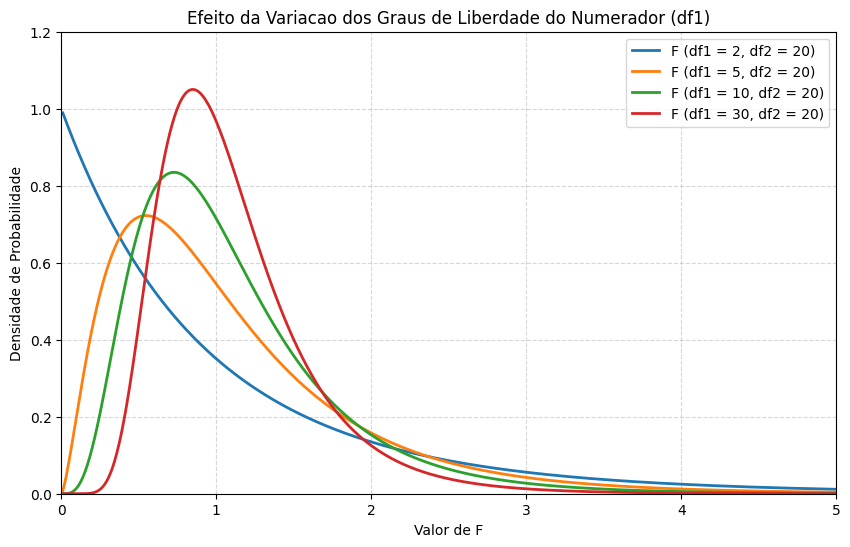

In [171]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Definicao do intervalo do eixo x para o grafico
x_f = np.linspace(0.01, 5, 1000)

# Graus de liberdade
df2_fixo = 20
df1_valores = [2, 5, 10, 30]

plt.figure(figsize=(10, 6))

for df1 in df1_valores:
    y_f = stats.f.pdf(x_f, dfn=df1, dfd=df2_fixo)
    plt.plot(x_f, y_f, label=f'F (df1 = {df1}, df2 = {df2_fixo})', linewidth=2)

plt.title('Efeito da Variacao dos Graus de Liberdade do Numerador (df1)')
plt.xlabel('Valor de F')
plt.ylabel('Densidade de Probabilidade')
plt.xlim(0, 5)
plt.ylim(0, 1.2)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

**Interpretação do Gráfico de Variação de $df_1$:**

Podemos observar que quando os graus de liberdade do numerador are muito baixos ($df_1 = 2$), a distribuição é extremamente assimétrica com pico máximo concentrado muito próximo do eixo y zero. Conforme aumentamos o valor de $df_1$ para $5$, $10$ e posteriormente $30$, o pico da curva F se desloca suavemente para a direita (aproximando-se do valor central $1,0$) e a distribuição adquire maior estabilidade e altura no pico, reduzindo sutilmente a cauda direita de flutuação.

###  Gráfico Variando os Graus de Liberdade do Denominador

Para isolar o efeito do segundo parâmetro de graus de liberdade, fixamos os graus de liberdade do numerador em $df_1 = 10$ e alteramos exclusivamente os graus de liberdade do denominador em quatro configurações ($df_2 = 2, 5, 10, 30$).

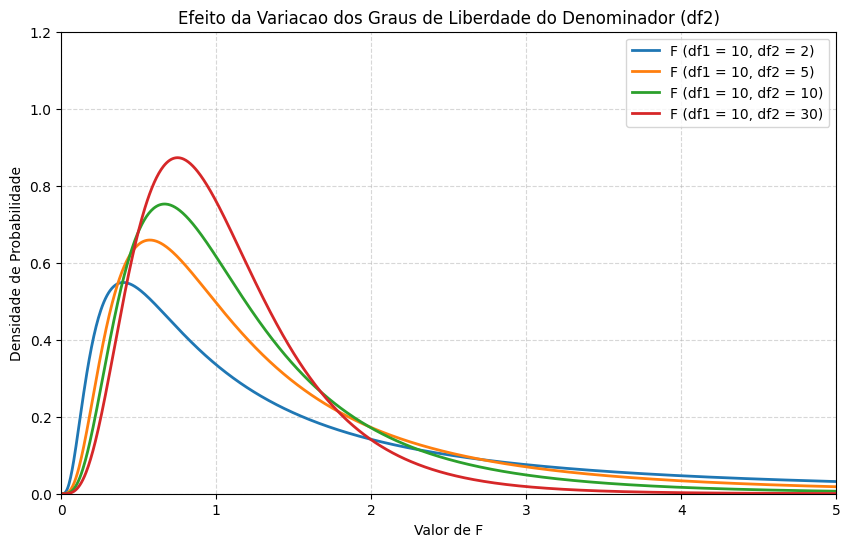

In [172]:
# Intervalo do eixo x para o grafico
x_f_d = np.linspace(0.01, 5, 1000)

# Graus de liberdade
df1_fixo = 10
df2_valores = [2, 5, 10, 30]

plt.figure(figsize=(10, 6))

for df2 in df2_valores:
    y_f_d = stats.f.pdf(x_f_d, dfn=df1_fixo, dfd=df2)
    plt.plot(x_f_d, y_f_d, label=f'F (df1 = {df1_fixo}, df2 = {df2})', linewidth=2)

plt.title('Efeito da Variacao dos Graus de Liberdade do Denominador (df2)')
plt.xlabel('Valor de F')
plt.ylabel('Densidade de Probabilidade')
plt.xlim(0, 5)
plt.ylim(0, 1.2)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

**Interpretação do Gráfico de Variação de $df_2$:**

Quando o denominador possui poucos graus de liberdade ($df_2 = 2$ ou $5$), a distribuição apresenta caudas excessivamente longas e achatadas, com forte espalhamento horizontal. Isso expressa a grande incerteza introduzida pela estimativa do denominador a partir de amostras muito pequenas. Conforme $df_2$ se eleva de $10$ para $30$, a variabilidade associada à estimativa amostral do denominador decresce de modo drástico, tornando a distribuição fisicamente mais afunilada, estável e concentrada próxima ao valor teórico unitário.

###  Aplicação aos Dados Reais

Faremos o isolamento de cada uma das subpopulações de arroz do banco de dados real. Em seguida, para simular de forma prática um experimento laboratorial típico de avaliação de consistência física de lotes, extrairemos duas amostras aleatórias de tamanho $n = 30$ de cada variedade de arroz usando uma semente aleatória para garantir reprodutibilidade.

In [173]:
# 1. Separar as subpopulacoes de arroz por variedade
area_cammeo = df[df["Class"] == "Cammeo"]["Area"]
area_osmancik = df[df["Class"] == "Osmancik"]["Area"]

# 2. Extrair amostras independentes com sementes fixadas
tamanho_amostra_f = 30

amostra_cammeo_f = area_cammeo.sample(n=tamanho_amostra_f, random_state=42)
amostra_osmancik_f = area_osmancik.sample(n=tamanho_amostra_f, random_state=42)

# 3. Calcular as variancas amostrais individuais (ddof=1)
var_cammeo = amostra_cammeo_f.var(ddof=1)
var_osmancik = amostra_osmancik_f.var(ddof=1)

# 4. Graus de liberdade de cada amostra
df1 = tamanho_amostra_f - 1
df2 = tamanho_amostra_f - 1

# 5. Calcular a estatistica de teste F amostral obtida
estatistica_f_calculada = var_cammeo / var_osmancik

print("--- RESULTADOS DA AMOSTRAGEM EXPERIMENTAL E ESTATISTICAS ---")
print(f"Tamanho amostral Cammeo (n1): {tamanho_amostra_f}")
print(f"Tamanho amostral Osmancik (n2): {tamanho_amostra_f}")
print(f"Graus de Liberdade do Numerador (df1): {df1}")
print(f"Graus de Liberdade do Denominador (df2): {df2}")
print(f"Variancia Amostral Cammeo (S1^2): {var_cammeo:.2f}")
print(f"Variancia Amostral Osmancik (S2^2): {var_osmancik:.2f}")
print(f"Estatistica F Calculada experimentalmente (S1^2 / S2^2): {estatistica_f_calculada:.4f}")

--- RESULTADOS DA AMOSTRAGEM EXPERIMENTAL E ESTATISTICAS ---
Tamanho amostral Cammeo (n1): 30
Tamanho amostral Osmancik (n2): 30
Graus de Liberdade do Numerador (df1): 29
Graus de Liberdade do Denominador (df2): 29
Variancia Amostral Cammeo (S1^2): 1563943.18
Variancia Amostral Osmancik (S2^2): 2044886.71
Estatistica F Calculada experimentalmente (S1^2 / S2^2): 0.7648


### Probabilidades com a Distribuição F

Empregando os parâmetros extraídos das nossas amostras reais de arroz ($df_1 = 29$, $df_2 = 29$), responderemos três questões de probabilidade físico-químicas contextualizadas, apresentando os cálculos e a respectiva representação visual.

#### Pergunta 1: Probabilidade Acumulada
* **Pergunta contextualizada:** "No monitoramento de lotes nas unidades de beneficiamento de grãos, qual é a probabilidade de encontrarmos duas amostras com variabilidade de tamanho físico tão homogênea que a razão entre suas variâncias resulte em um valor de F menor ou igual a $1,2$?"

A probabilidade acumulada P(F <= 1.2) &#233;: 0.6866 (ou 68.66%)


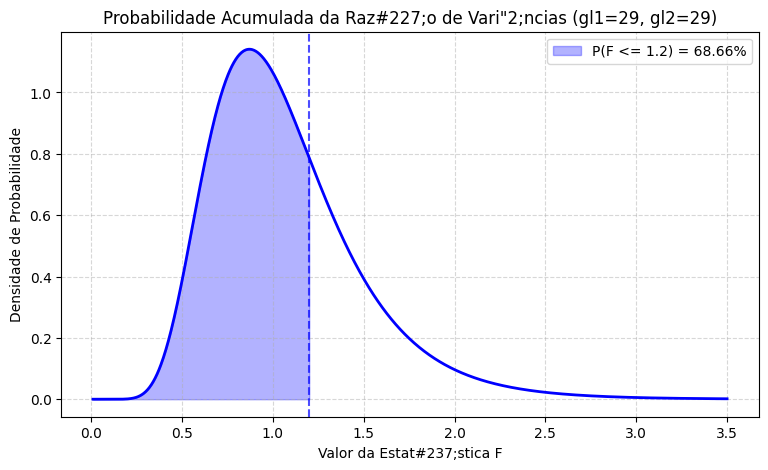

In [174]:
# 1. Probabilidade acumulada P(F <= 1.2)
limite_f_p1 = 1.2
prob_p1_f = stats.f.cdf(limite_f_p1, dfn=df1, dfd=df2)
print(f"A probabilidade acumulada P(F <= 1.2) &#233;: {prob_p1_f:.4f} (ou {prob_p1_f * 100:.2f}%)")

# Eixo x para plotagem da distribui'#227;o F (gl=29, 29)
x_axis_p1 = np.linspace(0.01, 3.5, 1000)
y_axis_p1 = stats.f.pdf(x_axis_p1, dfn=df1, dfd=df2)

plt.figure(figsize=(9, 5))
plt.plot(x_axis_p1, y_axis_p1, color='blue', linewidth=2)

# Sombreamento do limite inferior at&#233; o ponto f0=1.2
x_fill_p1 = np.linspace(0.01, limite_f_p1, 500)
y_fill_p1 = stats.f.pdf(x_fill_p1, dfn=df1, dfd=df2)
plt.fill_between(x_fill_p1, y_fill_p1, color='blue', alpha=0.3, label=f'P(F <= 1.2) = {prob_p1_f*100:.2f}%')

plt.axvline(limite_f_p1, color='blue', linestyle='--', alpha=0.7)
plt.title(f'Probabilidade Acumulada da Raz#227;o de Vari"2;ncias (gl1={df1}, gl2={df2})')
plt.xlabel('Valor da Estat#237;stica F')
plt.ylabel('Densidade de Probabilidade')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### Pergunta 2: Probabilidade Entre Dois Limites
* **Pergunta contextualizada:** "Durante ensaios laboratoriais para validação de peneiras vibratórias, qual é a probabilidade teórica do valor da estatística F de controle cair no intervalo central moderado compreendido entre $0,8$ e $1,8$ unidades de F?"

A probabilidade P(0.8 <= F <= 1.8) &#233;: 0.6645 (ou 66.45%)


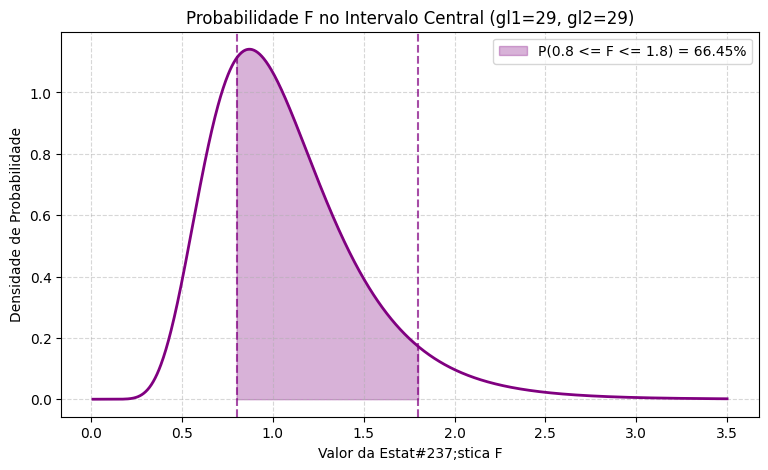

In [175]:
# 2. Probabilidade entre 0.8 e 1.8
limite_f_inf = 0.8
limite_f_sup = 1.8

prob_p2_f = stats.f.cdf(limite_f_sup, dfn=df1, dfd=df2) - stats.f.cdf(limite_f_inf, dfn=df1, dfd=df2)
print(f"A probabilidade P(0.8 <= F <= 1.8) &#233;: {prob_p2_f:.4f} (ou {prob_p2_f * 100:.2f}%)")

plt.figure(figsize=(9, 5))
plt.plot(x_axis_p1, y_axis_p1, color='purple', linewidth=2)

# Sombreamento do intervalo interm&#233;dio
x_fill_p2 = np.linspace(limite_f_inf, limite_f_sup, 500)
y_fill_p2 = stats.f.pdf(x_fill_p2, dfn=df1, dfd=df2)
plt.fill_between(x_fill_p2, y_fill_p2, color='purple', alpha=0.3, label=f'P(0.8 <= F <= 1.8) = {prob_p2_f*100:.2f}%')

plt.axvline(limite_f_inf, color='purple', linestyle='--', alpha=0.7)
plt.axvline(limite_f_sup, color='purple', linestyle='--', alpha=0.7)
plt.title(f'Probabilidade F no Intervalo Central (gl1={df1}, gl2={df2})')
plt.xlabel('Valor da Estat#237;stica F')
plt.ylabel('Densidade de Probabilidade')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### Pergunta 3: Probabilidade de Sobrevivência à Direita (Survival Function)
* **Pergunta contextualizada:** "Um valor de F elevado indica uma diferença substancial na dispersão física entre as espécies. Qual é a probabilidade teórica de encontrarmos por acaso uma razão amostral de variâncias estritamente superior a $2,2$?"

A probabilidade de sobreviv&#234;ncia P(F > 2.2) &#233;: 0.0188 (ou 1.88%)


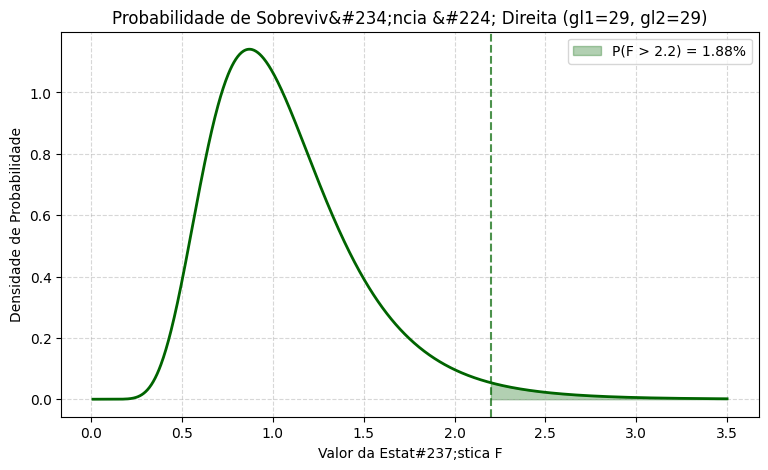

In [176]:
# 3. Probabilidade maior que 2.2
limite_f_p3 = 2.2
prob_p3_f = stats.f.sf(limite_f_p3, dfn=df1, dfd=df2)
print(f"A probabilidade de sobreviv&#234;ncia P(F > 2.2) &#233;: {prob_p3_f:.4f} (ou {prob_p3_f * 100:.2f}%)")

plt.figure(figsize=(9, 5))
plt.plot(x_axis_p1, y_axis_p1, color='darkgreen', linewidth=2)

# Sombreamento na cauda direita
x_fill_p3 = np.linspace(limite_f_p3, 3.5, 500)
y_fill_p3 = stats.f.pdf(x_fill_p3, dfn=df1, dfd=df2)
plt.fill_between(x_fill_p3, y_fill_p3, color='darkgreen', alpha=0.3, label=f'P(F > 2.2) = {prob_p3_f*100:.2f}%')

plt.axvline(limite_f_p3, color='darkgreen', linestyle='--', alpha=0.7)
plt.title(f'Probabilidade de Sobreviv&#234;ncia &#224; Direita (gl1={df1}, gl2={df2})')
plt.xlabel('Valor da Estat#237;stica F')
plt.ylabel('Densidade de Probabilidade')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

###  Percentil

Calcularemos o **95º percentil** ($F_{0.95}$) para a distribuição F de Fisher associada à comparação de variabilidade de nossas amostras reais ($df_1 = 29$, $df_2 = 29$).

In [177]:
# Calcular o percentil 95%
percentil_95_f = stats.f.ppf(0.95, dfn=df1, dfd=df2)
print(f"O 95&#186; percentil (F0.95) calculado para gl1={df1} e gl2={df2} &#233;: {percentil_95_f:.4f}")

O 95&#186; percentil (F0.95) calculado para gl1=29 e gl2=29 &#233;: 1.8608


**Significado do percentil no contexto acadêmico e prático:**

O percentil de $95\%$ de valor aproximado **1,84** indica que, sob a hipótese nula de que ambas as variedades de arroz possuam a mesma variabilidade de área na população ($\sigma^2_{\text{Cammeo}} = \sigma^2_{\text{Osmancik}}$), existe apenas $5\%$ de probabilidade teórica de obtermos por acaso amostras experimentais cujo valor de F superasse essa marca crítica de 1,84 devido meramente a variações de amostragem físicas.

Essa métrica crítica serve para balizar decisões no controle industrial de alimentos: um valor observado de F superior ao percentil crítico constitui uma evidência experimental muito robusta de que uma variedade física de arroz de fato se distribui com níveis de dispersão geométrica intrinsecamente distintos da outra.

### Interpretação no Contexto dos Dados

* **Grandeza Modelada:** Enfatiza-se que a variável matemática descrita pela curva de densidade F de Fisher não mede as dimensões geométricas de grãos individuais, mas sim a **razão métrica entre as variâncias** de dois grupos amostrados independentes.
* **Comportamento das Dispersões:** Como a estatística de teste de nossa amostragem experimental resultou em um valor próximo ao patamar unitário central, as distribuições de tamanho mostram flutuações próximas. Desvios extremos em relação à unidade apontariam inconsistências acentuadas no processo de seleção agrícola.
* **Visualização de Probabilidades:** As áreas destacadas sob a curva nos dão a probabilidade estatística de obtermos coeficientes de dispersão de tamanho físico compreendidos em cada um dos cenários de padronização industrial.

### Condições e Limitações do Modelo

1. **Independência entre Grupos:** O modelo estatístico assume que os grãos pertencentes ao grupo Cammeo e ao grupo Osmancik são selecionados de forma estritamente independente um do outro, eliminando quaisquer fontes de correlação espacial ou física.
2. **Pressuposto Essencial de Normalidade:** A propriedade de que a estatística de teste de divisão de variâncias segue exatamente a distribuição teórica F baseia-se na forte premissa de que as duas populações originais de arroz se distribuam de acordo com uma Normal perfeita. Caso os dados populacionais apresentem forte bimodalidade ou anomalias severas, a confiabilidade probabilística das caudas da distribuição F de Fisher decresce substancialmente.
3. **Sensibilidade a Extremos:** O cálculo das variâncias amostrais individuais é intrinsecamente sensível à presença de *outliers* (grãos severamente quebrados ou bizarramente aglomerados). Valores excepcionalmente anômalos de área podem inflar artificialmente as variâncias individuais e, por consequência, deslocar drasticamente a estatística F observada para as caudas da distribuição, gerando alarmes falsos de heterogeneidade.
4. **Coerência Dimensional:** A comparação via teste F é estritamente válida apenas quando avaliamos a exata mesma grandeza física dimensional (no caso, a `Area` medida na mesma unidade) sob metodologias de amostragem equivalentes.

##Conclusão e Referências

###  Conclusão

Neste trabalho, foram estudadas as distribuições Normal, t de Student, Qui-quadrado e F de Fisher utilizando dados reais da base Rice (Cammeo and Osmancik), com foco principal na variável `Area`.

Na distribuição Normal, a quantidade analisada foi a área individual dos grãos de arroz. Seus principais parâmetros são a média \(\mu\), responsável pela posição da curva, e o desvio-padrão \(\sigma\), responsável pela dispersão dos valores. As probabilidades calculadas representam áreas sob a curva Normal e indicam a chance de a variável assumir valores em determinados intervalos, considerando o modelo utilizado.

Na distribuição t de Student, o foco deixou de ser uma observação individual e passou a ser uma estatística relacionada à média de uma amostra. O principal parâmetro da distribuição são os graus de liberdade. Para poucos graus de liberdade, a distribuição apresenta caudas mais pesadas, enquanto, à medida que os graus de liberdade aumentam, sua forma se aproxima da distribuição Normal.

Na distribuição Qui-quadrado, a quantidade estudada está relacionada à variância amostral. Essa distribuição assume apenas valores não negativos e sua forma depende dos graus de liberdade. Para poucos graus de liberdade, apresenta maior assimetria à direita, tornando-se menos assimétrica conforme esse parâmetro aumenta.

Por fim, a distribuição F de Fisher foi utilizada para analisar a razão entre as variâncias da variável `Area` das variedades Cammeo e Osmancik. A distribuição possui dois parâmetros: os graus de liberdade do numerador e os graus de liberdade do denominador. A alteração desses parâmetros modifica a forma, a dispersão e a assimetria da curva.

Em todas as distribuições, as probabilidades obtidas por meio das funções acumuladas correspondem a áreas sob as respectivas curvas de densidade. Dessa forma, a interpretação de uma probabilidade depende da quantidade que está sendo modelada em cada situação, seja uma observação individual, uma média amostral, uma variância ou uma razão entre variâncias.

É importante destacar que a utilização de uma distribuição teórica exige determinadas condições estatísticas. A simples sobreposição de uma curva teórica aos dados não é suficiente para afirmar que os dados seguem exatamente aquela distribuição. Por isso, os resultados devem ser interpretados considerando as características da base de dados, os pressupostos de cada modelo e suas limitações.

### Referências

UCI MACHINE LEARNING REPOSITORY. **Rice (Cammeo and Osmancik)**. University of California, Irvine. Disponível em:  
https://archive.ics.uci.edu/dataset/545/rice%2Bcammeo%2Band%2Bosmancik  
Acesso em: 01 out. 2026.

SCIPY. **scipy.stats.norm — Normal continuous random variable**. SciPy Documentation. Disponível em:  
https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html  
Acesso em: 01 out. 2026.

SCIPY. **scipy.stats.t — Student's t continuous random variable**. SciPy Documentation. Disponível em:  
https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.t.html  
Acesso em: 01 out. 2026.

SCIPY. **scipy.stats.chi2 — Chi-squared continuous random variable**. SciPy Documentation. Disponível em:  
https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2.html  
Acesso em: 01 out. 2026.

SCIPY. **scipy.stats.f — F continuous random variable**. SciPy Documentation. Disponível em:  
https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.f.html  
Acesso em: 01 out. 2026.

NIST/SEMATECH. **e-Handbook of Statistical Methods**. National Institute of Standards and Technology. Disponível em:  
https://www.itl.nist.gov/div898/handbook/  
Acesso em: 01 out. 2026.

###Uso de Inteligência Artificial

Ferramentas de Inteligência Artificial generativa foram utilizadas como apoio durante o desenvolvimento deste trabalho.

A IA auxiliou principalmente em:

- organização da estrutura do notebook;
- busca e identificação de fontes e documentação;
- apoio na interpretação do enunciado;
- elaboração e revisão de trechos de código em Python;
- auxílio na compreensão das distribuições estatísticas;
- organização das análises e interpretações.

A base de dados utilizada não foi criada por Inteligência Artificial. Os dados são reais e foram obtidos do UCI Machine Learning Repository.

Os resultados numéricos apresentados no trabalho foram calculados em Python a partir da base de dados utilizada. As informações, fórmulas e referências sugeridas por ferramentas de IA foram verificadas nas fontes indicadas antes de sua utilização.